## Inspección del CSV

In [3]:
import pandas as pd

df = pd.read_csv("GlobalLandTemperaturesByCountry.csv")

df.head()


,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  object 
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.6+ MB


In [5]:
df.describe()

,AverageTemperature,AverageTemperatureUncertainty
count,544811.000000,545550.000000
mean,17.193354,1.019057
std,10.953966,1.201930
min,-37.658000,0.052000
25%,10.025000,0.323000
50%,20.901000,0.571000
75%,25.814000,1.206000
max,38.842000,15.003000


In [6]:
df.columns

Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'Country'], dtype='object')

In [7]:
df.isnull().sum()

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df[df["AverageTemperature"] > 60]
df[df["AverageTemperature"] < -90]

,dt,AverageTemperature,AverageTemperatureUncertainty,Country


## Convirtiendo fechas 

In [10]:
df["dt"] = pd.to_datetime(df["dt"])
df["year"] = df["dt"].dt.year
df["month"] = df["dt"].dt.month

# Gráficos Simples

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

## Aumento de la temperatura global

In [38]:
yearly = df.groupby("year")["AverageTemperature"].mean()


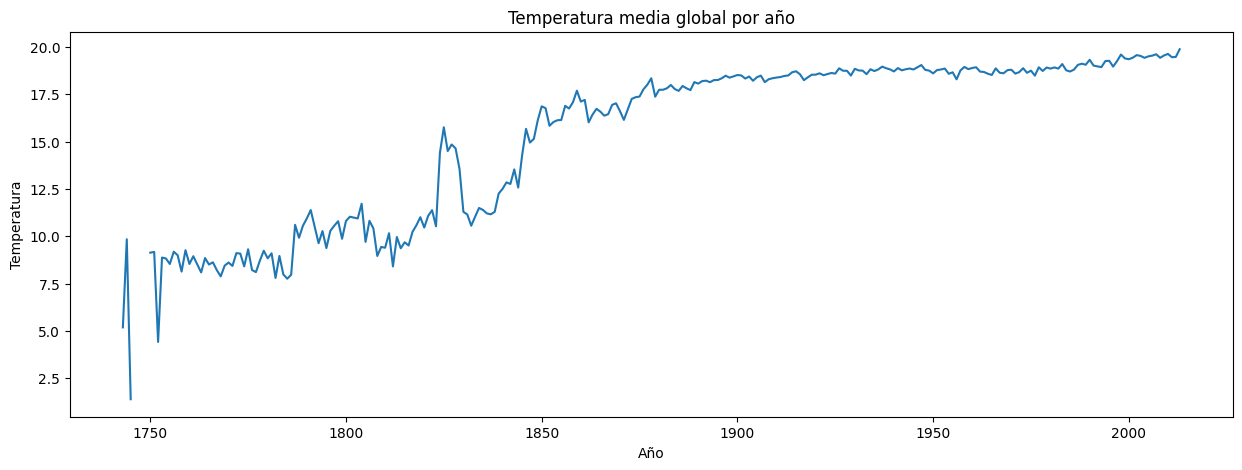

In [39]:
plt.figure(figsize=(15,5))
plt.plot(yearly.index, yearly.values)
plt.title("Temperatura media global por año")
plt.xlabel("Año")
plt.ylabel("Temperatura")
plt.show()

### Picos extraños: ~1825~
### Valores imposibles: None
### Años faltantes: ~1750~

In [16]:
# Check year and month columns
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year,month
0,1743-11-01,4.384,2.294,Åland,1743,11
1,1743-12-01,NaN,NaN,Åland,1743,12
2,1744-01-01,NaN,NaN,Åland,1744,1
3,1744-02-01,NaN,NaN,Åland,1744,2
4,1744-03-01,NaN,NaN,Åland,1744,3


<Axes: xlabel='year', ylabel='AverageTemperature'>

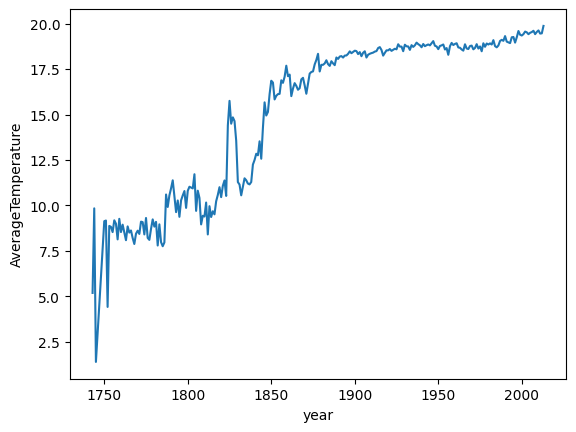

In [ ]:
sns.lineplot(data=df,  x="year", y="AverageTemperature", errorbar=None)

## Distribución

<Axes: xlabel='AverageTemperature', ylabel='Count'>

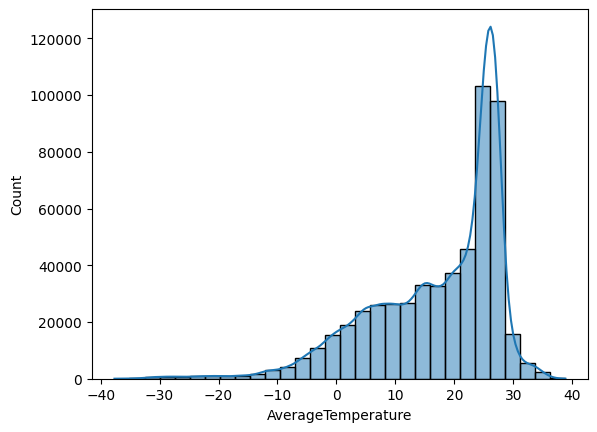

In [40]:
sns.histplot(df["AverageTemperature"], bins=30, kde=True)

### Forma unimodal aproximadamente acampanada. Cierta asimetria con sesgo hacia la izquierda. Parece razonable al ser una serie climática global.

<h2 style="margin: 8px 0 4px 0;">Media móvil (MA: Moving Average)</h3>
<div style="line-height: 1.75;">Suavización de ruido:<br>
&bull; En cada punto se calcula el promedio de los ultimos N puntos (MA_N)<br>
&bull; En este caso MA_10 al tratarse de una serie Mensual con bastantes cambios estacionales<br>
&bull; Recomendado MA_3 o MA_5 para series horarias/diarias. Pero diferencia case by case<br>
</div>

In [51]:
# Moving average of 10 months  
df["MA_10"] = df["AverageTemperature"].rolling(10).mean()

# dt to datatime already done

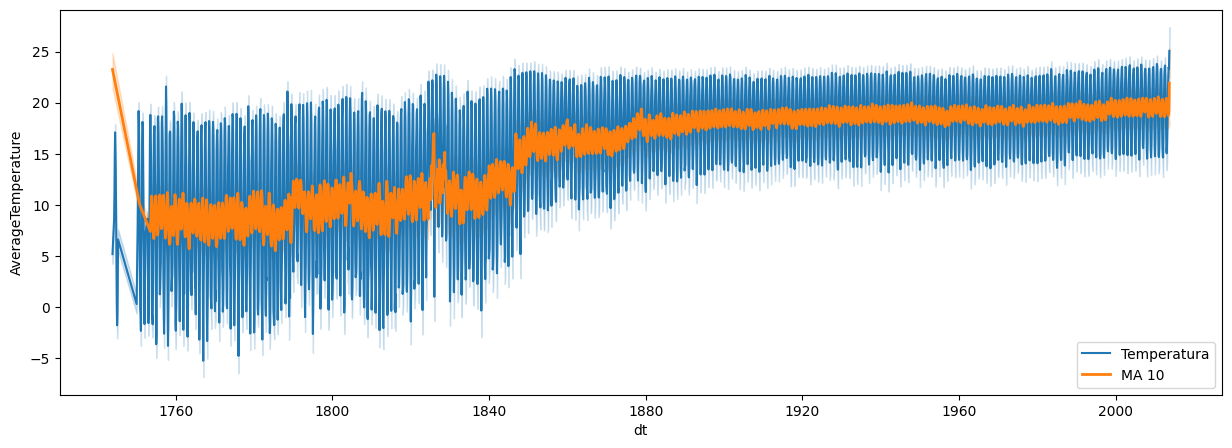

In [50]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x="dt", y="AverageTemperature", label="Temperatura")
sns.lineplot(data=df, x="dt", y="MA_10", label="MA 10", linewidth=2)

plt.show()

<h3 style="margin: 8px 0 4px 0;">Línea móvil</h3>
<div style="line-height: 1.25;">
<span style="color:blue;">Azul:</span> Variabilidad climática real (Estacional + extremos)<br>
<span style="color:darkorange;">Naranja:</span> Tendencia subyacente del clima
</div>

### Estudio de cambio climático con MA 50

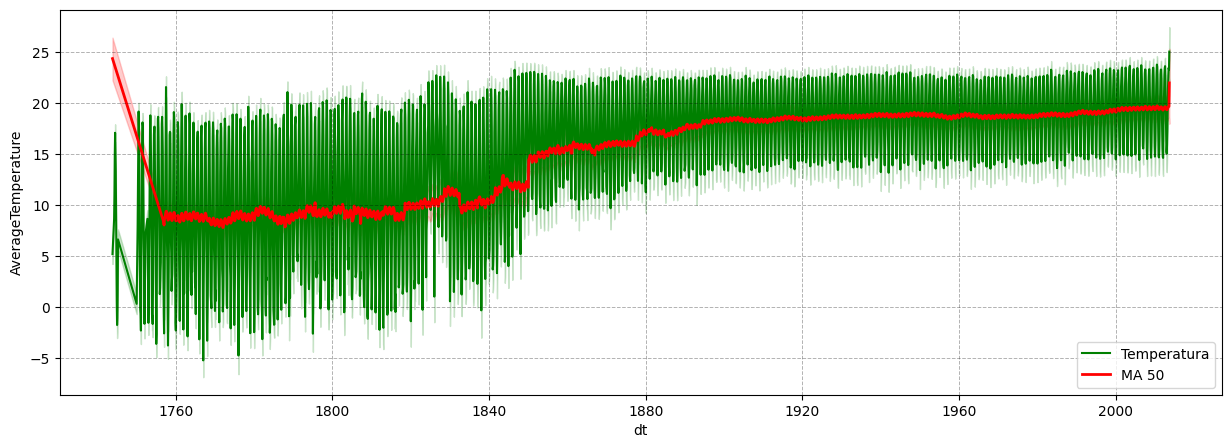

In [58]:
df["MA_50"] = df["AverageTemperature"].rolling(50).mean()
# Ligero cambio de color para diferenciar mejor las líneas
plt.figure(figsize=(15,5))
ax = plt.gca() # Obtener el eje actual para ajustar el grid encima de las líneas

sns.lineplot(
    data=df,
    x="dt",
    y="AverageTemperature",
    label="Temperatura",
    linewidth=1.5,
    color="green")
sns.lineplot(
    data=df,
    x="dt",
    y="MA_50",
    label="MA 50",
    linewidth=2,
    color="red")

# Ajustar el grid para que esté encima de las líneas
ax.set_axisbelow(False)
ax.grid(
    True,
    color = "black",
    linewidth=0.7,
    alpha=0.3,
    linestyle="--"
)

plt.show()